# Why the "Blur" works
In standard CNNs, when you use a MaxPooling2D or a Conv2D with strides=2, you are downsampling the image. Mathematically, downsampling without low-pass filtering (blurring) causes aliasing—a phenomenon where high-frequency patterns (like the sharp edges of a digit) become jagged or distorted.

By placing a DepthwiseConv2D with a fixed Gaussian-like (binomial) blur before the pooling layer, you are implementing a technique known as BlurPool. This makes the model more shift-invariant, meaning if a digit is moved by just one or two pixels, the internal representation (feature map) stays almost identical.

# Effectiveness for EMNIST
Thin vs. Thick Strokes: EMNIST digits are 28x28 grayscale. Some samples have very thin strokes. Standard pooling can "miss" or "break" these thin lines if they align poorly with the pooling grid. A slight blur ensures the line "spreads" enough to be captured reliably by the next layer.

## Upright Digits: 
Since your digits are upright, you don't need rotation invariance, but you do benefit from translation (shift) invariance. The fixed blur layer helps the network ignore tiny spatial shifts that occur in handwritten data.

## No Learned Noise: 
Because you set trainable=False, you are forcing the network to maintain this mathematical "sanity check" rather than letting it learn a noisy filter that might overfit to the training set.

# Implementation Check
For EMNIST grayscale (1 channel), the DepthwiseConv2D needs to handle the dimensions correctly. In the code I provided earlier, I included a helper get_blur_weights(channels). This is crucial because:

In the first block, it applies the blur to 32 feature maps.

In the second block, it applies it to 64.

Each channel is blurred independently, preserving the specific features (like edges or loops) detected by the preceding Conv2D.

# Summary Table

| Feature | Impact on EMNIST |
| :--- | :--- |
| Shift Invariance | Improves; handles "jitter" in handwriting. |
| Thin Strokes | Better preserved; less likely to disappear during pooling. |
| Aliasing | Reduced; prevents noise in deep feature maps. |
| Parameters | 0 new trainable parameters; efficient for small datasets. |

While both "zoom-out + blur" and DepthwiseConv2D (BlurPool) involve blurring, they serve different purposes and operate at different stages of the pipeline

| Feature | Pre-processing (Zoom + Blur) | Model Structure (DepthwiseConv2D) |
| :--- | :--- | :--- |
| **Stage** | Before the model sees the data. | Deep inside the hidden layers. |
| **Purpose** | Teaches the model robustness to low-quality or distant inputs. | Ensures Shift Invariance during downsampling (pooling). |
| **Effect** | "Spreads" the pixels of the original input digit. | "Spreads" the abstract features (edges, loops, curves) detected by filters. |
| **Mathematical Goal** | Increasing dataset diversity. | Preventing aliasing (signal distortion) inside the CNN. |

# Will Zoom + Blur "Simulate" the Layer?
Not exactly, but they are complementary.

## Zooming Out: 
This actually makes the lines thinner and smaller relative to the 28x28 frame. If you then add a Gaussian blur, you are essentially "fuzzing" the digit. This helps the model learn to recognize digits even when they are small or out of focus.

## The DepthwiseConv2D Layer: 
This layer is active after a Conv2D layer has already turned the image into feature maps (e.g., a map that only highlights vertical edges). Blurring here ensures that if a vertical edge moves 1 pixel to the left, the "blurred" version still overlaps significantly with the original position, making the model much more stable.

## Which one "spreads" the line better?
If your goal is to ensure the line "spreads" enough to be captured reliably:

### The Model Layer is more effective for "Capture": 
It acts as a safety net every time the image gets smaller (pooling). It prevents the "disappearing pixel" problem that happens during Max Pooling.

### The Pre-processing is better for "Generalization": 
It forces the model to work harder during training to find the "true" shape of the digit amidst the blur.

## Recommendation
If you want the best results for EMNIST, keep the DepthwiseConv2D layer and add the Zoom/Blur to your augmentation if you have a very small dataset. However, your initial requirement stated "No Layer/Dataset level Augmentation." If you must stick to that rule, the DepthwiseConv2D is the superior choice because it is a mathematical property of the architecture (Anti-Aliasing) rather than a modification of the training data. It makes the model inherently "smarter" about how it looks at shapes.

## Zooming In:
That correction changes the perspective significantly! If you zoom-in (enlarge the digit) and then blur it, you are effectively performing "Data Dilation."

Here is how that compares to the DepthwiseConv2D layer in your model:

### The "Thick Line" Simulation
When you zoom-in + blur in preprocessing, you are manually creating a "Bold" version of the digit.

#### Zoom-in: 
Stretches the digit, making the strokes physically occupy more pixels.

#### Blur: 
Softens the edges of those stretched strokes, making them look like they were written with a thicker marker or a felt-tip pen.

### Does this "Simulate" the DepthwiseConv2D?
In a way, yes, but at a different "resolution" of the logic:

#### Pre-processing (Zoom-In + Blur): 
Makes the input more robust. It tells the model: "A '1' is still a '1' even if the person used a thick marker." It helps the first layer of the CNN capture features more easily because there is "more" signal to grab onto.

#### Model Layer (DepthwiseConv2D): 
Makes the internal features more robust. It tells the model: "I don't care exactly which pixel this edge is on, just that an edge exists in this general area."

### The Synergy (How they work together)
If you use both, you create a very "stable" vision system:

The Pre-processing ensures the lines are never too thin for the first Conv2D filters to "miss."

The DepthwiseConv2D ensures that as the signal travels deeper into the network and gets smaller (via Pooling), the "thickness" or "presence" of that line isn't lost due to mathematical sampling errors (aliasing).

| Action | Result on Line | Benefit |
| :--- | :--- | :--- |
| **Zoom-In + Blur** | Physical Thickness | Prevents "Empty" filters in the first layer; simulates different pens. |
| **DepthwiseConv2D** | Feature Persistence | Prevents the line from "flickering" or disappearing during downsampling. |

# Making Convolutional Networks Shift-Invariant Again

| Feature | Zhang (2019) Recommendation | Your Implementation (BlurPooling.txt) |
| :--- | :--- | :--- |
| **Filter Placement** | Directly before any subsampling layer. | Applied before MaxPooling2D in Blocks 1 and 2. |
| **Filter Type** | Fixed (non-trainable) binomial kernels. | `trainable=False` with constant binomial weights. |
| **Operation** | DepthwiseConv2D for efficiency. | Used DepthwiseConv2D to process channels independently. |
| **Kernel Size** | 3x3 or 5x5 filters. | Implemented as a 3x3 kernel. |


# Reference:
1. Gemini: https://gemini.google.com/share/75b200e41b27
2. Making Convolutional Networks Shift-Invariant Again (2019) Richard Zhang 1

2026-03-08 18:51:34.027838: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772995894.233116      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772995894.292862      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772995894.778149      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772995894.778211      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772995894.778215      17 computation_placer.cc:177] computation placer alr

--- Loading EMNIST Digits from local PNG folders ---
Found 240000 files belonging to 10 classes.
Using 192000 files for training.


2026-03-08 18:54:25.719777: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 240000 files belonging to 10 classes.
Using 48000 files for validation.
Found 40000 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing_head (Sequential) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 28, 28, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 14, 14, 64)     │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 7, 7, 128)      │         1,152 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,57

 Total params: 132,205 (516.43 KB)

 Trainable params: 129,226 (504.79 KB)

 Non-trainable params: 2,979 (11.64 KB)

Epoch 1/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9359 - loss: 0.3103
Epoch 1: val_accuracy improved from -inf to 0.97650, saving model to emnist_best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 479s 198ms/step - accuracy: 0.9359 - loss: 0.3102 - val_accuracy: 0.9765 - val_loss: 0.1470 - learning_rate: 0.0010
Epoch 2/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9889 - loss: 0.1067
Epoch 2: val_accuracy did not improve from 0.97650
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 314s 171ms/step - accuracy: 0.9889 - loss: 0.1067 - val_accuracy: 0.8394 - val_loss: 0.5642 - learning_rate: 0.0010
Epoch 3/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9913 - loss: 0.0788
Epoch 3: val_accuracy improved from 0.97650 to 0.97815, saving model to emnist_best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 317s 169ms/step - accuracy: 0.9913 - loss: 0.0788 - val_accuracy: 0.9781 - val_loss: 0.1084 - learning_rate: 0.0010
Epoch 4/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 

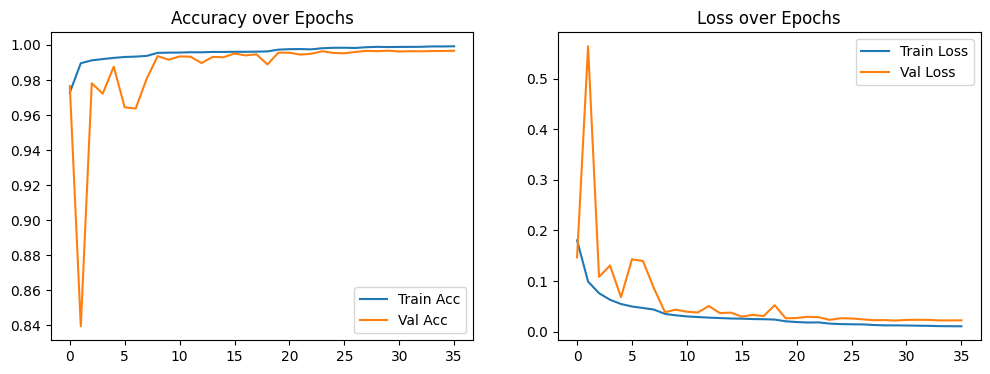

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00      4000
           2       1.00      1.00      1.00      4000
           3       1.00      1.00      1.00      4000
           4       1.00      1.00      1.00      4000
           5       1.00      1.00      1.00      4000
           6       1.00      1.00      1.00      4000
           7       1.00      1.00      1.00      4000
           8       1.00      1.00      1.00      4000
           9       1.00      1.00      1.00      4000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000


Accuracy (Test Set): 0.9971


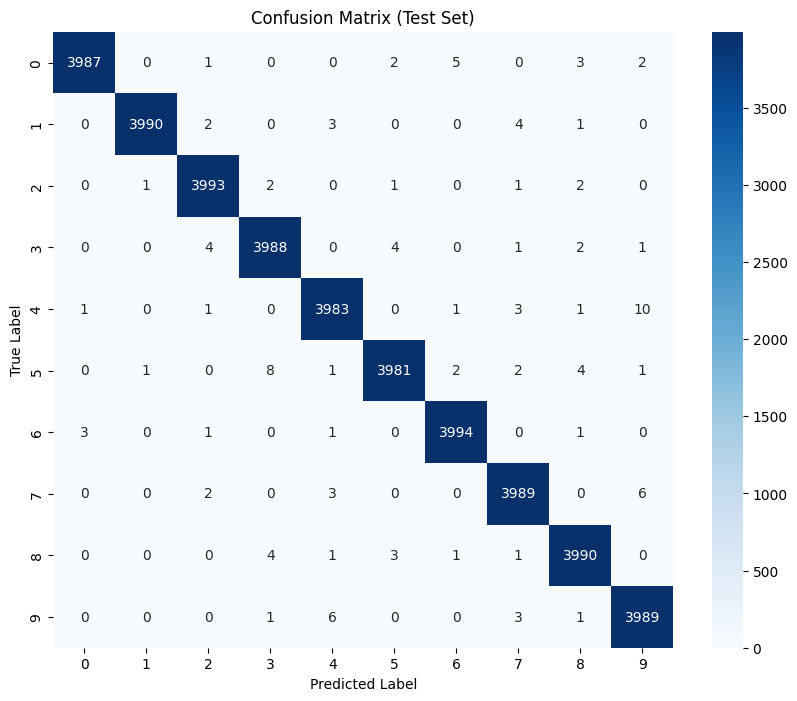

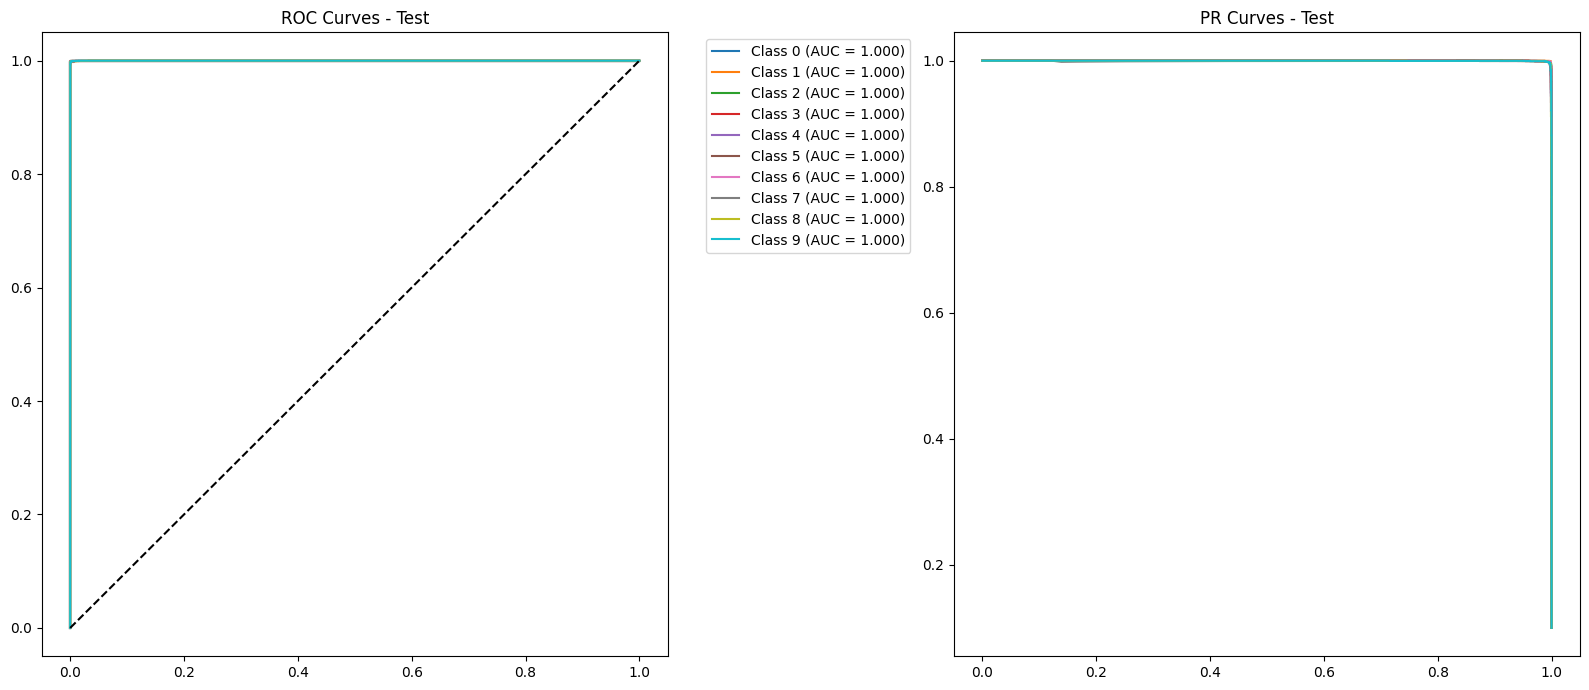

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, 
                             average_precision_score, confusion_matrix, 
                             classification_report, accuracy_score)
from sklearn.preprocessing import label_binarize

# Download latest version
DATA_DIR = "/kaggle/input/emnist-digits-balanced"

def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    # Global access and constants
    IMG_SIZE = (28, 28)
    BATCH_SIZE = 128
    SEED = 42

    # 1. Load TRAIN dataset
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # 2. Load TEST dataset
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=f"{DATA_DIR}/test",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Class names:", class_names)

    # 4. Normalization layer (NO augmentation)
    norm_layer = layers.Normalization(axis=None)
    # Adapt on a mapping to ensure the stats are based on [0, 1] range
    norm_layer.adapt(
        train_ds.map(lambda x, y: x / 255.0).take(500)
    )

    preprocessing_model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Rescaling(1./255),
        norm_layer
    ], name="preprocessing_head")

    # 5. Final pipeline
    def finalize(ds, shuffle=False):
        if shuffle:
            ds = ds.shuffle(10000, seed=SEED)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = finalize(train_ds, shuffle=True)
    val_ds = finalize(val_ds)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, preprocessing_model


def build_blur_cnn(preprocessing_layer):
    l2_reg = regularizers.l2(1e-4)
    
    # Corrected Kernel Weights for DepthwiseConv2D
    # Shape must be (filter_height, filter_width, in_channels, channel_multiplier)
    # For grayscale (1 channel), shape is (3, 3, 1, 1)
    kernel_weights = np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype='float32')
    kernel_weights /= kernel_weights.sum()
    
    # We will expand the dims inside the layer call or use a constant initializer
    # For a 32-filter layer, we need to match the depth. 
    # A cleaner way is to reshape to (3, 3, 1, 1) if applying to 1 channel 
    # OR use a custom layer. Here we use the Constant initializer correctly.
    
    def get_blur_weights(channels):
        # Create weights of shape (3, 3, channels, 1)
        w = np.zeros((3, 3, channels, 1), dtype='float32')
        for i in range(channels):
            w[:, :, i, 0] = kernel_weights
        return w

    model = models.Sequential([
        preprocessing_layer,

        # --- Block 1 ---
        layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.DepthwiseConv2D(kernel_size=3, strides=1, padding='same', use_bias=False, 
                               depthwise_initializer=tf.keras.initializers.Constant(get_blur_weights(32)), 
                               trainable=False), 
        layers.MaxPooling2D(pool_size=(2, 2)),

        # --- Block 2 ---
        layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.DepthwiseConv2D(kernel_size=3, strides=1, padding='same', use_bias=False, 
                               depthwise_initializer=tf.keras.initializers.Constant(get_blur_weights(64)), 
                               trainable=False),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # --- Block 3 ---
        layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.DepthwiseConv2D(kernel_size=3, strides=1, padding='same', use_bias=False, 
                               depthwise_initializer=tf.keras.initializers.Constant(get_blur_weights(128)), 
                               trainable=False),
        layers.GlobalAveragePooling2D(),

        # --- Dense Head ---
        layers.Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Initialize
train_data, val_data, test_data, prep_layer = get_keras_dataset()
model = build_blur_cnn(prep_layer)
model.summary()

# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
checkpoint = callbacks.ModelCheckpoint("emnist_best_model.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# Train
history = model.fit(
    train_data,
    epochs=250,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Plotting
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Evaluation logic
def get_actual_and_probabilities(dataset):
    y_true = []
    y_probs = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_probs.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_probs)

def plot_evaluation_curves(y_true_labels, y_probs, class_names, set_name="Test"):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true_labels, classes=range(n_classes))
    
    plt.figure(figsize=(16, 7))
    plt.subplot(1, 2, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curves - {set_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.subplot(1, 2, 2)
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f'Class {class_names[i]}')
    plt.title(f'PR Curves - {set_name}')
    plt.tight_layout()
    plt.show()

# Final Evaluation
target_names = [str(i) for i in range(10)]
y_test_true, y_test_probs = get_actual_and_probabilities(test_data)

# Get predicted labels for the test set
y_test_pred = np.argmax(y_test_probs, axis=1)

# 1. Print classification report
print("Classification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

# 2. Print accuracy on test set
accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"\nAccuracy (Test Set): {accuracy:.4f}")

# 3. Plot confusion matrix for test set
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_true, y_test_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plot_evaluation_curves(y_test_true, y_test_probs, target_names, set_name="Test")